In [1]:
import numpy as np
import pandas as pd

In [ ]:

df_life_expectancy_New=pd.read_excel("C:\\Users\\manis\\OneDrive\\Desktop\\Data Analytics Module\\Life_Expectancy_Assgn.xlsx")#Create a dataframe by reading the excel file

In [ ]:
df_life_expectancy_New['Economy_Status']=np.where(df_life_expectancy_New['Economy_status_Developed']==1,'Developed','Developing')#Create a new column 'Economy_Status' based on the values in 'Economy_status_Developed' column. If the value is 1, it will be labeled as 'Developed', otherwise it will be labeled as 'Developing'.

In [4]:
print(df_life_expectancy_New.head())

            Country                         Region  Year  Infant_deaths  \
0           Hungary                 European Union  2000            8.7   
1       Afghanistan                           Asia  2000           90.5   
2   Solomon Islands                        Oceania  2000           25.6   
3  Congo, Dem. Rep.                         Africa  2000          106.5   
4          Honduras  Central America and Caribbean  2000           30.3   

   Under_five_deaths  Adult_mortality  Alcohol_consumption  Hepatitis_B  \
0               10.1         192.9690                12.23           88   
1              129.2         310.8305                 0.02           62   
2               30.7         228.1690                 0.71           81   
3              159.3         344.2520                 2.05           69   
4               37.0         171.7060                 2.47           93   

   Measles   BMI  ...  Incidents_HIV  GDP_per_capita  Population_mln  \
0       99  25.9  ...     

In [ ]:
df_grouped=df_life_expectancy_New.groupby('Economy_Status')['GDP_per_capita'].mean().reset_index()#Group the dataframe by 'Economy_Status' and calculate the mean of 'GDP_per_capita' for each group. The result is stored in a new dataframe called 'df_grouped'.

In [7]:
print(df_grouped.head())

  Economy_Status  GDP_per_capita
0      Developed    33683.547297
1     Developing     5771.368398


In [8]:
summary_stats = df_life_expectancy_New.groupby(['Year', 'Economy_Status'])['GDP_per_capita'].describe()
print(summary_stats)

print(summary_stats)

                     count          mean           std     min       25%  \
Year Economy_Status                                                        
2000 Developed        37.0  30136.675676  20239.837506  3718.0  12312.00   
     Developing      142.0   5065.253521   9053.381066   148.0    963.75   
2001 Developed        37.0  30631.756757  20438.261451  3937.0  12735.00   
     Developing      142.0   5056.873239   8898.509975   163.0   1043.25   
2002 Developed        37.0  31068.216216  20551.854492  4260.0  12960.00   
     Developing      142.0   5093.345070   8924.578212   192.0   1022.00   
2003 Developed        37.0  31510.972973  20565.337898  4519.0  13428.00   
     Developing      142.0   5228.450704   9066.886874   202.0   1064.25   
2004 Developed        37.0  32491.243243  21078.571784  4850.0  14070.00   
     Developing      142.0   5451.112676   9406.164743   213.0   1112.75   
2005 Developed        37.0  33291.594595  21314.973009  5231.0  14978.00   
     Develop

In [5]:
import matplotlib.pyplot as plt

<Axes: ylabel='GDP_per_capita'>

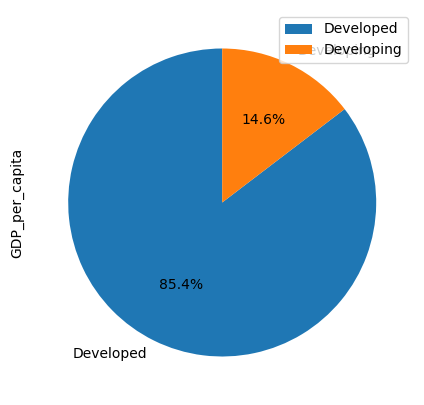

In [ ]:
df_grouped.plot.pie(
    y='GDP_per_capita',
    labels=df_grouped['Economy_Status'],
    autopct='%1.1f%%',
    startangle=90,
    figsize=(5, 5)
) #Create a pie chart using the 'GDP_per_capita' column from the 'df_grouped' dataframe. The labels for the pie chart are taken from the 'Economy_Status' column. The 'autopct' parameter formats the percentage values displayed on the chart, and 'startangle' rotates the chart to start at a specific angle. The 'figsize' parameter sets the size of the figure.

In [ ]:
df_new_data_1=df_life_expectancy_New[[ 'Adult_mortality','Alcohol_consumption','Hepatitis_B','Incidents_HIV','Economy_Status', 'BMI']] #Create a new dataframe called 'df_new_data_1' that contains only the specified columns from the 'df_life_expectancy_New' dataframe to understand the relationship between these variables and the economy status.

In [ ]:
df_new_data_grouped=df_new_data_1.groupby('Economy_Status').mean(numeric_only=True,).reset_index()#Group the 'df_new_data_1' dataframe by 'Economy_Status' and calculate the mean of the numeric columns for each group. The result is stored in a new dataframe called 'df_new_data_grouped'. The 'numeric_only=True' parameter ensures that only numeric columns are included in the mean calculation, and 'reset_index()' is used to reset the index of the resulting dataframe.

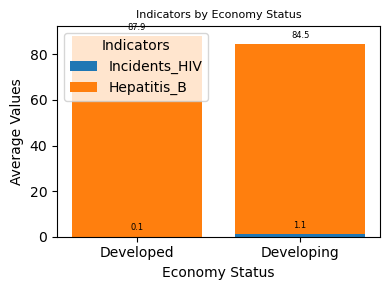

In [ ]:
import matplotlib.pyplot as plt
indicators = ['Incidents_HIV', 'Hepatitis_B']
data = df_new_data_grouped[indicators]
categories = df_new_data_grouped.index
x = np.arange(len(categories))
fig, ax = plt.subplots(figsize=(4, 3))
bottom = np.zeros(len(categories))
for indicator in indicators:
    values = data[indicator]
    bars = ax.bar(categories, values, bottom=bottom, label=indicator)
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=6)
    bottom += values
ax.set_xlabel('Economy Status', fontsize=10)
ax.set_ylabel('Average Values', fontsize=10)
ax.set_title('Indicators by Economy Status', fontsize=8)
ax.legend(title='Indicators')
plt.tight_layout()
ax.set_xticks([0, 1])
ax.set_xticklabels(['Developed', 'Developing'])
plt.show()  #Create a stacked bar chart to compare the average values of 'Incidents_HIV' and 'Hepatitis_B' indicators between 'Developed' and 'Developing' economy statuses. The x-axis represents the economy status, while the y-axis represents the average values of the indicators. Each bar is labeled with its corresponding value for better visualization.

In [15]:
print(df_new_data_1.head())

   Adult_mortality  Alcohol_consumption  Hepatitis_B  Incidents_HIV  \
0         192.9690                12.23           88           0.08   
1         310.8305                 0.02           62           0.02   
2         228.1690                 0.71           81           0.17   
3         344.2520                 2.05           69           1.07   
4         171.7060                 2.47           93           0.53   

  Economy_Status   BMI  
0      Developed  25.9  
1     Developing  21.7  
2     Developing  24.9  
3     Developing  20.7  
4     Developing  24.8  


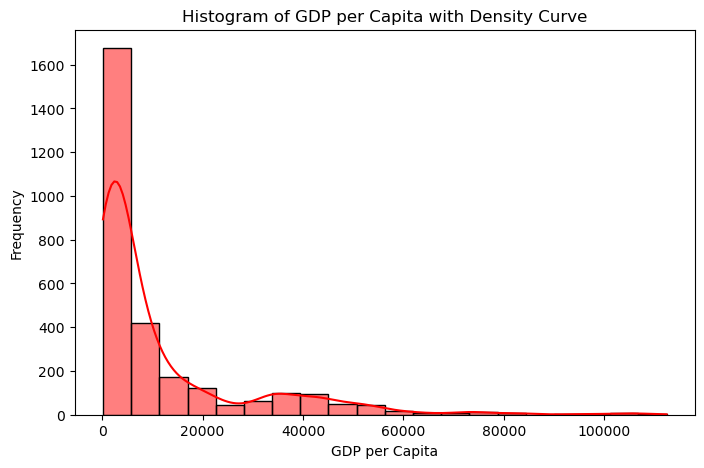

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(
    df_life_expectancy_New['GDP_per_capita'], 
    bins=20, 
    color='red', 
    kde=True  # ✅ adds the smooth curve
)
plt.xlabel('GDP per Capita')
plt.ylabel('Frequency')
plt.title('Histogram of GDP per Capita with Density Curve')
plt.show()  #Create a histogram of the 'GDP_per_capita' column from the 'df_life_expectancy_New' dataframe. The histogram will have 20 bins and will be colored red. Additionally, a kernel density estimate (KDE) curve will be added to the histogram to show the distribution of the data more smoothly. The x-axis will be labeled 'GDP per Capita', the y-axis will be labeled 'Frequency', and the title of the plot will be 'Histogram of GDP per Capita with Density Curve'. Finally, the plot will be displayed using plt.show().

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px

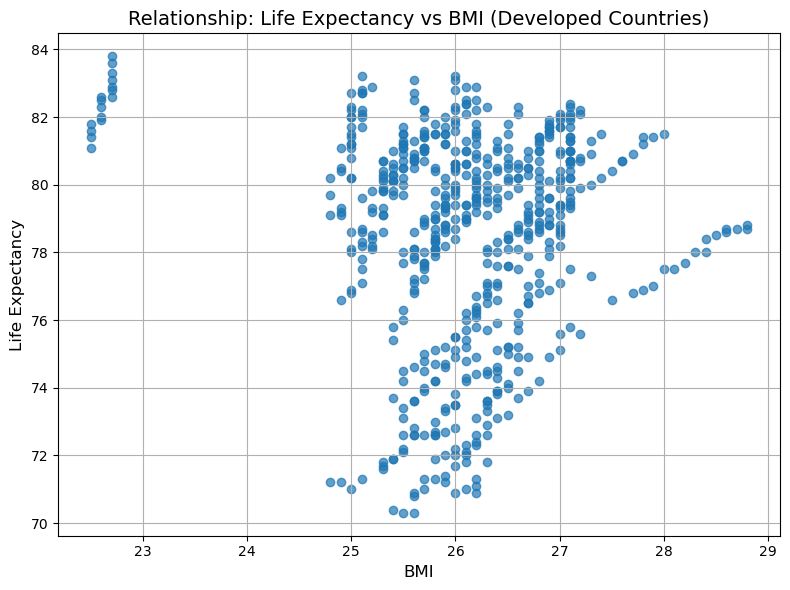

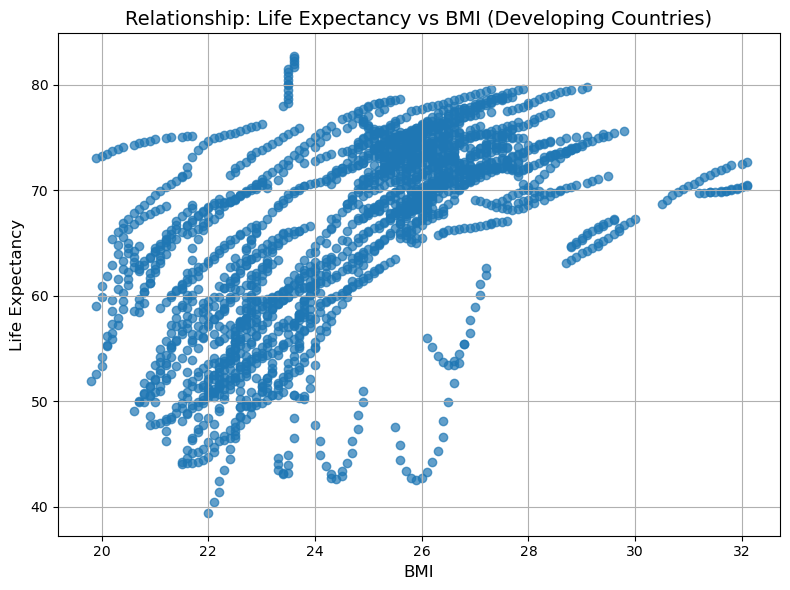

In [ ]:
developed_df = df_life_expectancy_New[
    df_life_expectancy_New["Economy_Status"] == "Developed"
]
plt.figure(figsize=(8,6))
plt.scatter( developed_df["BMI"],
developed_df["Life_expectancy"], alpha=0.7)
plt.xlabel("BMI", fontsize=12)
plt.ylabel("Life Expectancy", fontsize=12)
plt.title("Relationship: Life Expectancy vs BMI (Developed Countries)", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()
developing_df = df_life_expectancy_New[
    df_life_expectancy_New["Economy_Status"] == "Developing"
]
plt.figure(figsize=(8,6))
plt.scatter( developing_df["BMI"],
developing_df["Life_expectancy"], alpha=0.7)
plt.xlabel("BMI", fontsize=12)
plt.ylabel("Life Expectancy", fontsize=12)
plt.title("Relationship: Life Expectancy vs BMI (Developing Countries)", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show() #Create two scatter plots to visualize the relationship between 'BMI' and 'Life_expectancy' for 'Developed' and 'Developing' economy statuses separately. The first plot will show the relationship for developed countries, while the second plot will show the relationship for developing countries. Each plot will have appropriate labels, titles, and gridlines for better visualization. Finally, both plots will be displayed using plt.show().

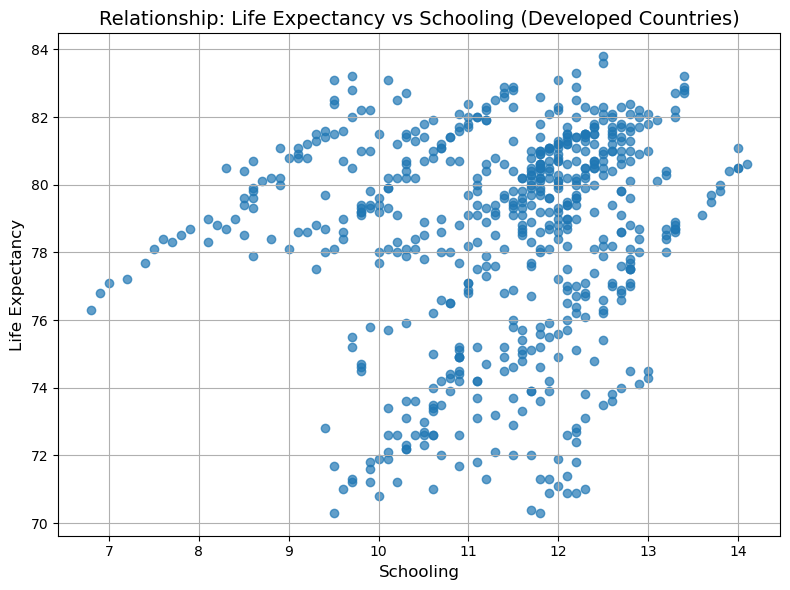

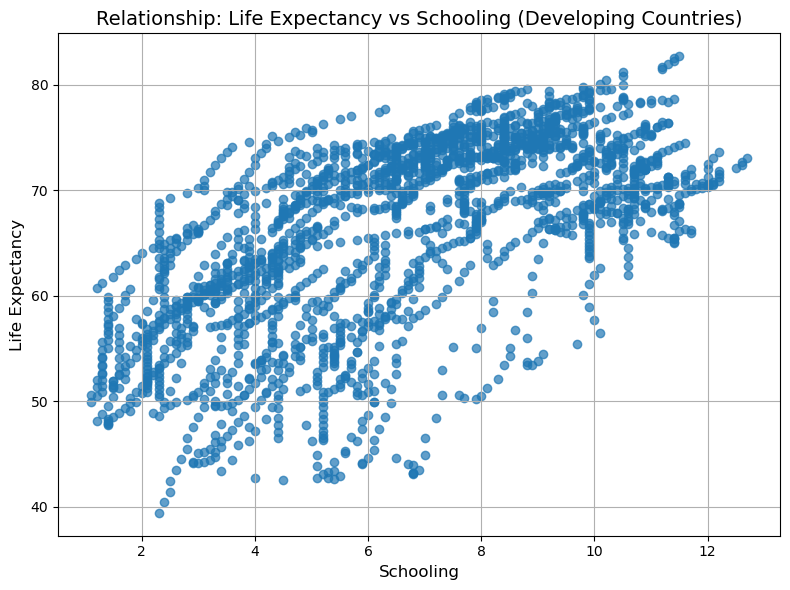

In [ ]:
developed_df = df_life_expectancy_New[
    df_life_expectancy_New["Economy_Status"] == "Developed"
]
plt.figure(figsize=(8,6))
plt.scatter( developed_df["Schooling"],
developed_df["Life_expectancy"], alpha=0.7)
plt.xlabel("Schooling", fontsize=12)
plt.ylabel("Life Expectancy", fontsize=12)
plt.title("Relationship: Life Expectancy vs Schooling (Developed Countries)", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()
developing_df = df_life_expectancy_New[
    df_life_expectancy_New["Economy_Status"] == "Developing"
]
plt.figure(figsize=(8,6))
plt.scatter( developing_df["Schooling"],
developing_df["Life_expectancy"], alpha=0.7)
plt.xlabel("Schooling", fontsize=12)
plt.ylabel("Life Expectancy", fontsize=12)
plt.title("Relationship: Life Expectancy vs Schooling (Developing Countries)", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show() #Create two scatter plots to visualize the relationship between 'Schooling' and 'Life_expectancy' for 'Developed' and 'Developing' economy statuses separately. The first plot will show the relationship for developed countries, while the second plot will show the relationship for developing countries. Each plot will have appropriate labels, titles, and gridlines for better visualization. Finally, both plots will be displayed using plt.show().

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df_life_expectancy_New[["BMI", "Life_expectancy", "Schooling"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #Standardize the features 'BMI', 'Life_expectancy', and 'Schooling' from the 'df_life_expectancy_New' dataframe using StandardScaler. The standardized features are stored in the variable 'X_scaled'. This step is important for clustering algorithms like KMeans since the variables are of different scale and unit of measurement. Standardizing the features ensures that each feature contributes equally to the distance calculations in the clustering algorithm, preventing any single feature from dominating the results due to its scale.

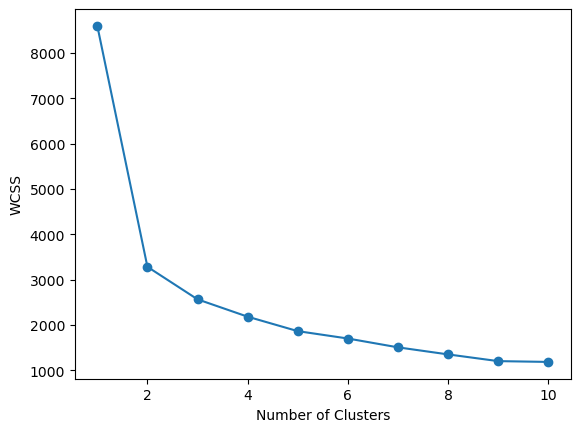

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1,11):
        kmeans = KMeans(n_clusters=k,
        random_state=42)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show() #Use the Elbow method to determine the optimal number of clusters for KMeans clustering. The code iterates through a range of cluster numbers (1 to 10), fits a KMeans model for each number of clusters, and calculates the within-cluster sum of squares (WCSS) for each model. The WCSS values are stored in a list and then plotted against the number of clusters to visualize the "elbow" point, which indicates the optimal number of clusters.

K=10, Silhouette Score=0.284


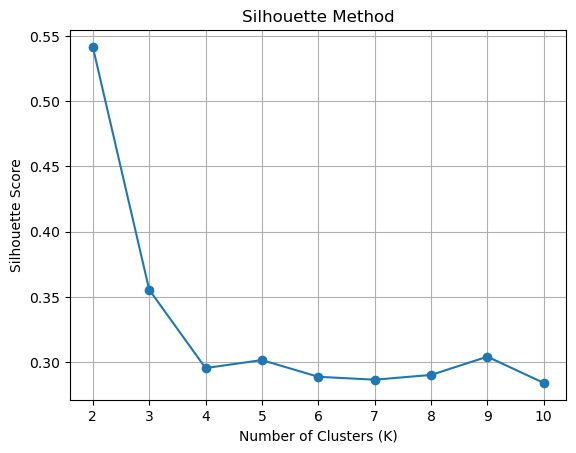

In [ ]:
from sklearn.metrics import silhouette_score
sil_scores = []
for k in range(2, 11):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        sil_scores.append(score)
print(f"K={k}, Silhouette Score={score:.3f}")
plt.figure()
plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.grid(True)
plt.show() #Use the Silhouette method to evaluate the optimal number of clusters for KMeans clustering. The code iterates through a range of cluster numbers (2 to 10), fits a KMeans model for each number of clusters, and calculates the silhouette score for each model. The silhouette scores are stored in a list and then plotted against the number of clusters to visualize which number of clusters has the highest silhouette score, indicating the best clustering solution.


In [ ]:

df_grouped = df_life_expectancy_New.groupby(['Country', 'Year'], as_index=False).agg({
    'BMI': 'mean',
    'Life_expectancy': 'mean',
    'Schooling': 'mean'
})
df_grouped = df_grouped.merge(
    df_life_expectancy_New[['Country', 'Year', 'Economy_Status']],
    on=['Country', 'Year'],
    how='left'
)
df_grouped['BMI_Cat'] = pd.cut(
    df_grouped['BMI'],
    bins=[0, 18.5, 25, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)
print(f"Number of country-year observations: {len(df_grouped)}")
X = df_grouped[['BMI','Schooling']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=2, random_state=42,n_init=10)
df_grouped['Cluster'] = kmeans.fit_predict(X_scaled).astype(str)

fig = px.scatter(
    df_grouped,
    x='Schooling',
    y='Life_expectancy',
    color='Cluster',
    hover_name='Country',      
    hover_data={'BMI': True, 'Life_expectancy': True,"Schooling":True,"BMI_Cat":True,"Economy_Status":True,"Cluster": True},
    labels={'BMI':'BMI', 'Life_expectancy':'Life Expectancy', 'Schooling':'Schooling'},
    title='Clusters of Countries (BMI, Life Expectancy, Schooling)',
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_layout(
    legend_title_text='Cluster',
    width=1000,
    height=700,
    xaxis=dict(title='Schooling'),
    yaxis=dict(title='Life Expectancy'),
)

fig.show() #Create a scatter plot using Plotly Express to visualize the clusters of countries based on their 'Schooling' and 'Life_expectancy' values. The points in the scatter plot are colored according to their assigned cluster, and hovering over each point will display additional information about the country, including its 'BMI', 'Life_expectancy', 'Schooling', 'BMI_Cat', 'Economy_Status', and 'Cluster'. The plot is customized with appropriate labels, title, and color scheme for better visualization. Finally, the plot is displayed using fig.show().

Number of country-year observations: 2864


In [ ]:
summary = df_grouped.groupby("Cluster").agg({
    "Life_expectancy": ["mean", "std", "min", "max"],
    "BMI": ["mean", "std", "min", "max"],
    "Schooling": ["mean", "std", "min", "max"]
}) #Calculate summary statistics (mean, standard deviation, minimum, and maximum) for 'Life_expectancy', 'BMI', and 'Schooling' for each cluster in the 'df_grouped' dataframe. The results are stored in a new dataframe called 'summary', which provides insights into the characteristics of each cluster based on these key variables.

In [18]:
print(summary)

        Life_expectancy                              BMI                  \
                   mean       std   min   max       mean       std   min   
Cluster                                                                    
0              74.00104  5.413228  42.7  83.8  26.348878  1.341140  22.1   
1              59.79161  7.993890  39.4  77.0  22.714465  1.302612  19.8   

              Schooling                       
          max      mean       std  min   max  
Cluster                                       
0        32.1  9.525178  2.038915  4.6  14.1  
1        25.9  4.296914  1.736701  1.1  10.4  


In [51]:
df_grouped.to_excel("cluster_output5.xlsx", index=False)

In [ ]:
df_bar = df_grouped[
    (df_grouped["Cluster"] == "0") &
    (df_grouped["BMI_Cat"]=="Normal")&
    (df_grouped["Year"]==2000)
]
df_bar = df_bar.sort_values("Life_expectancy", ascending=False)
fig = px.bar(
    df_bar,
    x="Country",
    y="Life_expectancy",
    color="BMI",
    title="Cluster 0 (2000): Life Expectancy (Normal BMI)",
    text="Life_expectancy"
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show() #Create a bar chart using Plotly Express to visualize the life expectancy of countries in Cluster 0 with a normal BMI category for the year 2000. The x-axis represents the countries, while the y-axis represents their life expectancy. The bars are colored based on their BMI values, and the life expectancy values are displayed as text on top of each bar. The x-axis labels are rotated for better readability, and the plot is displayed using fig.show().

In [ ]:
df_bar = df_grouped[
    (df_grouped["Cluster"] == "0") &
    (df_grouped["BMI_Cat"]=="Overweight")&
    (df_grouped["Year"]==2000)
]
df_bar = df_bar.sort_values("Life_expectancy", ascending=False)
fig = px.bar(
    df_bar,
    x="Country",
    y="Life_expectancy",
    color="BMI",
    title="Cluster 0 (2000): Life Expectancy (Overweight BMI)",
    text="Life_expectancy"
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show() #Create a bar chart using Plotly Express to visualize the life expectancy of countries in Cluster 0 with an overweight BMI category for the year 2000. The x-axis represents the countries, while the y-axis represents their life expectancy. The bars are colored based on their BMI values, and the life expectancy values are displayed as text on top of each bar. The x-axis labels are rotated for better readability, and the plot is displayed using fig.show().

In [ ]:
bins=[0,18.5,25,29.9, float('inf')]
labels=['Underweight','Normal','Overweight','Obese']
df_life_expectancy_New['BMI_Cat']=pd.cut(df_life_expectancy_New['BMI'],bins=bins,labels=labels) #Create a new column 'BMI_Cat' in the 'df_life_expectancy_New' dataframe by categorizing the 'BMI' values into four categories: 'Underweight', 'Normal', 'Overweight', and 'Obese'. The categorization is done using the pd.cut() function, which assigns labels to the specified bins of BMI values. The bins are defined as follows: BMI less than 18.5 is categorized as 'Underweight', BMI between 18.5 and 25 is categorized as 'Normal', BMI between 25 and 29.9 is categorized as 'Overweight', and BMI of 30 or higher is categorized as 'Obese'.

C:\Users\manis\AppData\Local\Temp\ipykernel_9176\3645791428.py:25: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



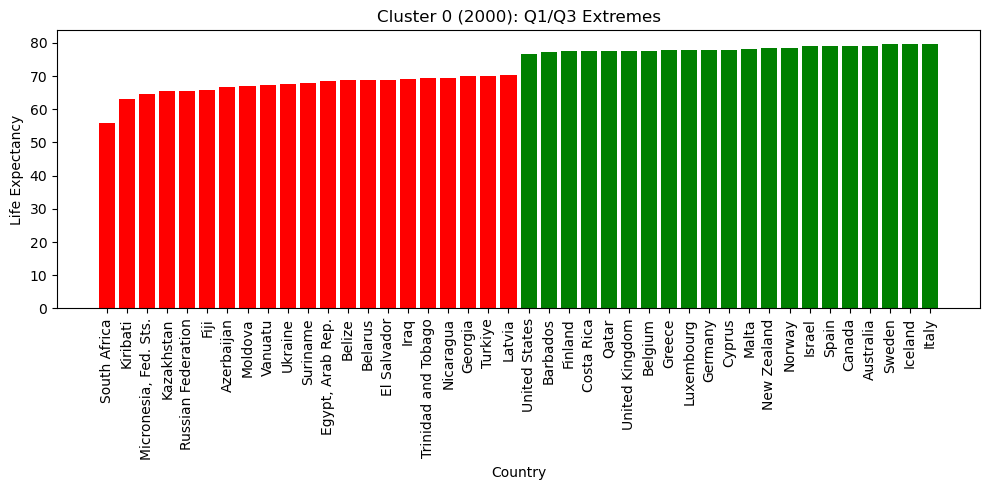

In [ ]:
df_2000_c0 = df_grouped[
    (df_grouped["Year"] == 2000) &
    (df_grouped["Cluster"] == "0")&
    (df_grouped["BMI_Cat"] == 'Overweight')
]
fig = px.scatter(
    df_2000_c0,
    x="BMI",
    y="Life_expectancy",
    hover_name="Country",
    trendline="ols",
    title="Cluster 0 (Year 2000): Life Expectancy vs Overweight BMI with Trend Line"
)
fig.show()
import plotly.express as px
fig = px.box(
    df_2000_c0,
    y="Life_expectancy",
    title="Cluster 0 (Year 2000): Box plot Life Expectancy in Overweight BMI"
)
fig.show()
q3 = df_2000_c0["Life_expectancy"].quantile(0.75)
q1 = df_2000_c0["Life_expectancy"].quantile(0.25)

df_2000_c0["group"] = "middle"
df_2000_c0.loc[df_2000_c0["Life_expectancy"] >= q3, "group"] = "high"
df_2000_c0.loc[df_2000_c0["Life_expectancy"] <= q1, "group"] = "low"
colors = df_2000_c0["group"].map({
    "high": "green",
    "low": "red"
})

extremes = df_2000_c0[df_2000_c0["group"] != "middle"].copy()
extremes = extremes.sort_values("Life_expectancy")

plt.figure(figsize=(10,5))

plt.bar(
    extremes["Country"],
    extremes["Life_expectancy"],
    color=colors.loc[extremes.index]
)

plt.xlabel("Country")
plt.ylabel("Life Expectancy")
plt.title("Cluster 0 (2000): Q1/Q3 Extremes")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show() #Create a bar chart to visualize the countries in Cluster 0 with an overweight BMI category for the year 2000, highlighting those with life expectancy values in the top and bottom quartiles. The bars are colored green for countries with life expectancy above the third quartile (Q3) and red for countries with life expectancy below the first quartile (Q1). The x-axis represents the countries, while the y-axis represents their life expectancy. The x-axis labels are rotated for better readability, and the plot is displayed using plt.show().



In [ ]:
df_2015_c0 = df_grouped[
    (df_grouped["Year"] == 2015) &
    (df_grouped["Cluster"] == "0")&
    (df_grouped["BMI_Cat"] == 'Overweight')
]
fig = px.scatter(
    df_2015_c0,
    x="BMI",
    y="Life_expectancy",
    hover_name="Country",
    trendline="ols",
    title="Cluster 0 (Year 2015): Life Expectancy vs Overweight BMI with Trend Line"
)
fig.show()
df_2015_c0 = df_grouped[
    (df_grouped["Year"] == 2015) &
    (df_grouped["Cluster"] == "0")&
    (df_grouped["BMI_Cat"] == 'Overweight')
]
import plotly.express as px
fig = px.box(
    df_2015_c0,
    y="Life_expectancy",
    title="Cluster 0 (Year 2015): Boxplot Life Expectancy in Overweight BMI"
)
fig.show() #Create a box plot using Plotly Express to visualize the distribution of 'Life_expectancy' for countries in Cluster 0 with an overweight BMI category for the year 2015. The y-axis represents life expectancy, and the title of the plot indicates the cluster, year, and BMI category being analyzed. The plot is displayed using fig.show().

In [ ]:
df_filtered = df_grouped[(df_grouped['Cluster'] == "0") & (df_grouped['BMI_Cat'] == 'Overweight')]
df_filtered = df_filtered[df_filtered['Year'].isin([2000, 2015])]
print(df_filtered.shape)
result = df_filtered.pivot_table(
    index='Country',
    columns='Year',
    values='Life_expectancy'
)
if len(result.columns) == 2:
    result.columns = ['Life_Expectancy_2000', 'Life_Expectancy_2015']
else:
    print("Columns found:", result.columns)
result['Change'] = result['Life_Expectancy_2015'] - result['Life_Expectancy_2000']
print(result)
result.to_excel("output.xlsx") #Create a new dataframe 'result' that contains the life expectancy values for countries in Cluster 0 with an overweight BMI category for the years 2000 and 2015. The dataframe is pivoted to have 'Country' as the index and 'Year' as the columns, with the corresponding life expectancy values as the values. A new column 'Change' is calculated to show the difference in life expectancy between 2015 and 2000. Finally, the resulting dataframe is exported to an Excel file named "output.xlsx".



(192, 8)
                     Life_Expectancy_2000  Life_Expectancy_2015  Change
Country                                                                
Albania                              74.0                  78.0     4.0
Algeria                               NaN                  76.1     NaN
Antigua and Barbuda                  73.9                  76.5     2.6
Argentina                            73.6                  76.1     2.5
Armenia                              71.4                  74.5     3.1
...                                   ...                   ...     ...
United States                        76.6                  78.7     2.1
Uruguay                              74.7                  77.4     2.7
Uzbekistan                            NaN                  70.9     NaN
Vanuatu                              67.4                  69.9     2.5
Venezuela, RB                        72.1                  72.6     0.5

[113 rows x 3 columns]


C:\Users\manis\AppData\Local\Temp\ipykernel_9176\517267354.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



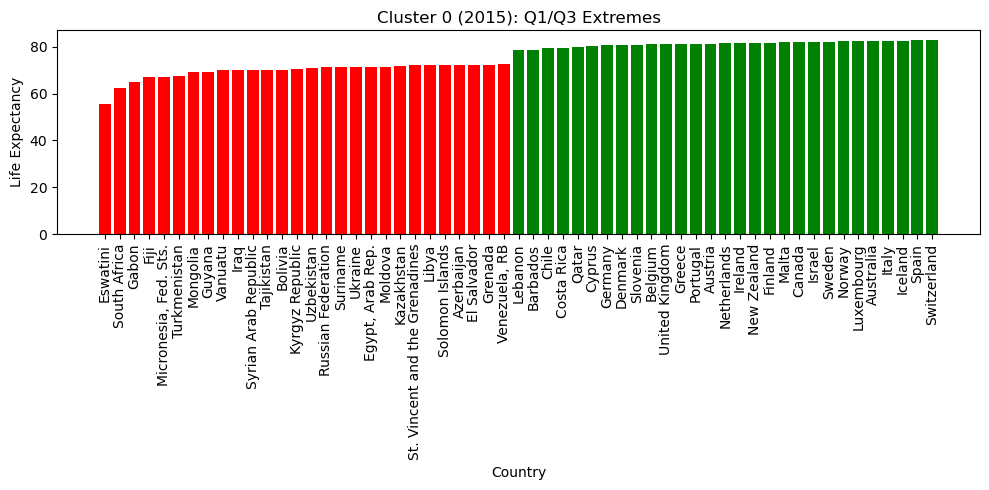

In [ ]:
q3 = df_2015_c0["Life_expectancy"].quantile(0.75)
q1 = df_2015_c0["Life_expectancy"].quantile(0.25)

df_2015_c0["group"] = "middle"
df_2015_c0.loc[df_2015_c0["Life_expectancy"] >= q3, "group"] = "high"
df_2015_c0.loc[df_2015_c0["Life_expectancy"] <= q1, "group"] = "low"
colors = df_2015_c0["group"].map({
    "high": "green",
    "low": "red"
})

extremes = df_2015_c0[df_2015_c0["group"] != "middle"].copy()
extremes = extremes.sort_values("Life_expectancy")

plt.figure(figsize=(10,5))

plt.bar(
    extremes["Country"],
    extremes["Life_expectancy"],
    color=colors.loc[extremes.index]
)

plt.xlabel("Country")
plt.ylabel("Life Expectancy")
plt.title("Cluster 0 (2015): Q1/Q3 Extremes")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show() #Create a bar chart to visualize the countries in Cluster 0 with an overweight BMI category for the year 2015, highlighting those with life expectancy values in the top and bottom quartiles. The bars are colored green for countries with life expectancy above the third quartile (Q3) and red for countries with life expectancy below the first quartile (Q1). The x-axis represents the countries, while the y-axis represents their life expectancy. The x-axis labels are rotated for better readability, and the plot is displayed using plt.show().

In [ ]:
df_2000_c0 = df_grouped[
    (df_grouped["Year"] == 2000) &
    (df_grouped["Cluster"] == "0")
]

fig = px.scatter(
    df_2000_c0,
    x="Schooling",
    y="Life_expectancy",
    hover_name="Country",
    trendline="ols",
    title="Cluster 0 (Year 2000): Schooling vs Life Expectancy with Trend Line"
)
fig.show() #Create scatter plots with trend lines to visualize the relationship between 'Schooling' and 'Life_expectancy' for Cluster 0 in the years 2000 and 2015. The first plot will show the relationship for the year 2000, while the second plot will show the relationship for the year 2015. Each plot will have appropriate labels, titles, and a trend line to indicate the overall trend in the data. Finally, both plots will be displayed using fig.show().

In [ ]:
df_2015_c0 = df_grouped[
    (df_grouped["Year"] == 2015) &
    (df_grouped["Cluster"] == "0")
]

fig = px.scatter(
    df_2015_c0,
    x="Schooling",
    y="Life_expectancy",
    hover_name="Country",
    trendline="ols",
    title="Cluster 0 (Year 2015): Schooling vs Life Expectancy with Trend Line"
)
fig.show() #Create scatter plots with trend lines to visualize the relationship between 'Schooling' and 'Life_expectancy' for Cluster 0 in the years 2000 and 2015. The first plot will show the relationship for the year 2000, while the second plot will show the relationship for the year 2015. Each plot will have appropriate labels, titles, and a trend line to indicate the overall trend in the data. Finally, both plots will be displayed using fig.show().